## SHOBHITH Sent me this code..

## I changed the code.. see the changes in the equation..

Ex.1-- Remove the current form of regularization..  Works without the regularization..

In [ ]:

import h5py
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint
import gc
import mne
import time
import sys
import os


from torchdiffeq import odeint

# --- Debugging Flags ---
use_half_precision = False
debug_interval = 100

# ---------- DATA LOADING + PREPROCESSING ----------
try:
    file_new_raw = '/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif'
    raw = mne.io.read_raw_fif(file_new_raw, preload=False)
    data_total, times_total = raw[322, 2000:7000]
    data,times= raw[322, 2000:6000]
    ecg_data = -data[0]
    ecg_data_total = -data_total[0]

    # Load the .mat file

    mat = loadmat("/home/shobs/Desktop/DDP/scout_id_309.mat")
    eeg_data_total = mat['Value'][:, 2000:7000]
    eeg_data = mat['Value'][:, 2000:6000]
    sc_data = loadmat('/home/shobs/Desktop/DDP/SC_CC120309-27.mat')
    sc_matrix = sc_data["sc"]

    max_val = np.max(sc_matrix)
    Sw_all = (sc_matrix / max_val) * 0.01 if max_val > 0 else sc_matrix

except FileNotFoundError as e:
    print(f"Error loading data files: {e}")
    sys.exit()

non_zero_indices_per_row = [np.nonzero(Sw_all[i, :])[0] for i in range(Sw_all.shape[0])]

def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized

ecg_processed = preprocess_signal(ecg_data, fs=1000, lowcut=1.5, highcut=20)
ecg_processed_total= preprocess_signal(ecg_data_total, fs=1000, lowcut=1.5, highcut=20)
eeg_processed = np.array([preprocess_signal(row, fs=1000, lowcut=0.5, highcut=30) for row in eeg_data])
eeg_processed_total = np.array([preprocess_signal(row, fs=1000, lowcut=0.5, highcut=30) for row in eeg_data_total])
# --- UTILITY FUNCTIONS ---
def simulate_coupled_oscillators(T=10, dt=1/1000, alpha=1, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=3.14, n=1.0, modulation=None):
    N = int(T / dt)
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        dr1 = alpha * r1 - r1**3 + coupling12 + (0.1*modulation[i,0] if modulation is not None and i < len(modulation) else 0)
        dr2 = alpha * r2 - r2**3 + coupling21 + (0.1*modulation[i,1] if modulation is not None and i < len(modulation) else 0)

        dphi1 = omega1 + A12 * r2 / r1 * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / r2 * np.sin(theta21 + n * (phi1 - phi2))

        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1), R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total_oscillators = num_regions * osc_per_region
    freqs_hz = np.random.uniform(low, high, total_oscillators)
    return 2 * np.pi * freqs_hz

def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            start_i, end_i = i * osc_per_region, (i + 1) * osc_per_region
            start_j, end_j = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[start_i:end_i, start_j:end_j] = intra_value
            else:
                rand_block = np.random.rand(osc_per_region, osc_per_region)
                rand_block *= Sc_region[i, j] / (rand_block.sum() + 1e-9)
                Sc_full[start_i:end_i, start_j:end_j] = rand_block
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full

def reset_weights(m):
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

# --- NEURAL NETWORK MODELS ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, feature_dim),
        )
        self.output_layer = nn.Linear(feature_dim, output_dim)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.output_layer(features)

    def get_features(self, x):
        return self.feature_extractor(x)


class OscillatorODEFunc(nn.Module):
    def __init__(self, N_osc, mu, k, omega, C, theta):
        super().__init__()

        self.N_osc = N_osc
        self.mu = mu
        self.k = k

        self.register_buffer("omega", omega)
        self.register_buffer("C", C)
        self.register_buffer("theta", theta)

        self.r_min = 0.001
        self.r_max = 2.0
        self.phase_clip = 2 * np.pi

        # self.input_f = None # Removed this as input_f will be passed via args to forward

    def forward(self, t, state):

        N = self.N_osc

        r = state[:N].unsqueeze(-1)
        phi = state[N:].unsqueeze(-1)

        # Dynamically get the input_f for the current time t from the sequence
        # Access input_features_sequence and t_eval_input from self
        if hasattr(self, 'input_features_sequence') and hasattr(self, 't_eval_input'):
            t_eval_input = self.t_eval_input
            input_features_sequence = self.input_features_sequence
            # Ensure t_eval_input and t are on the same device
            t_idx = torch.argmin(torch.abs(t_eval_input.to(t.device) - t)).long()
            input_f = input_features_sequence[t_idx].unsqueeze(-1) # (N_osc, 1)
        else:
            # Default to zero if no input sequence is provided (e.g., initial ODE func creation or debugging)
            input_f = torch.zeros_like(r) # (N_osc, 1)

        omega_i = self.omega.unsqueeze(-1)
        omega_j = self.omega.unsqueeze(0)

        C = self.C
        theta = self.theta

        phi_i = phi
        phi_j = phi.transpose(0, 1)

        phase_term = phi_j / omega_j - phi_i / omega_i + theta / (omega_i * omega_j)

        phase_term = torch.clamp(
            phase_term,
            -self.phase_clip,
            self.phase_clip
        )

        r_j = r.transpose(0, 1)
        r_safe = torch.clamp(r, self.r_min, self.r_max)

        coupling_r = self.k * torch.sum(
            C * r_j * torch.cos(omega_i * phase_term),
            dim=-1,
            keepdim=True
        )

        coupling_phi = self.k * torch.sum(
            C * (r_j / r_safe) * torch.sin(omega_i * phase_term),
            dim=-1,
            keepdim=True
        )

        dr_dt = (self.mu - r**2) * r + coupling_r + input_f
        dphi_dt = self.omega.unsqueeze(-1) + coupling_phi

        return torch.cat([
            dr_dt.squeeze(-1),
            dphi_dt.squeeze(-1)
        ])


class OscillatorLayer(nn.Module):

    def __init__(self,
                 N_osc=16,
                 T=4.0,
                 fs=100,
                 device="cpu",
                 coupling_sparsity=0.3,
                 seed=42):

        super().__init__()

        self.N_osc = N_osc
        self.T = T
        self.fs = fs
        self.dt = 1.0 / fs

        torch.manual_seed(seed)

        freqs = 2.0 + torch.rand(N_osc, device=device) * 8.0

        self.mu_param = nn.Parameter(torch.tensor(1.0, device=device))
        self.k_param = nn.Parameter(torch.tensor(0.01, device=device))
        self.omega_param = nn.Parameter(2 * torch.pi * freqs)

        mask = torch.rand(N_osc, N_osc, device=device) > coupling_sparsity
        mask.fill_diagonal_(False)

        C_val = torch.rand(N_osc, N_osc, device=device) * 0.02
        self.C_buffer = C_val * mask.float()

        theta_val = torch.zeros(N_osc, N_osc, device=device)
        theta_val.fill_diagonal_(0.0)
        self.theta_buffer = theta_val

        self.ode_func = OscillatorODEFunc(
            N_osc=N_osc,
            mu=self.mu_param,
            k=self.k_param,
            omega=self.omega_param,
            C=self.C_buffer,
            theta=self.theta_buffer
        )

        self.register_buffer("initial_r", torch.ones(N_osc, device=device) * 0.1)
        self.register_buffer("initial_phi", torch.zeros(N_osc, device=device))

        self.r_min = 0.01
        self.r_max = 2.0

    def forward(self, input_features_sequence): # Renamed to emphasize it's a sequence

        # input_features_sequence: (T_steps, N_osc)

        y0 = torch.cat([
            self.initial_r,
            self.initial_phi
        ])

        t_eval = torch.arange(
            0,
            self.T,
            self.dt,
            device=input_features_sequence.device,
            dtype=torch.float32
        )

        # Set input_features_sequence and t_eval as attributes of ode_func
        self.ode_func.input_features_sequence = input_features_sequence
        self.ode_func.t_eval_input = t_eval

        sol = odeint(
            self.ode_func,
            y0,
            t_eval,
            method="rk4"
            # args parameter is removed here
        )

        # Clean up temporary attributes
        del self.ode_func.input_features_sequence
        del self.ode_func.t_eval_input

        return sol




class ECGToOscillatorMLP(nn.Module):
    """ECG → MLP → OscillatorLayer → MLP → Brain drive [N]"""
    def __init__(self, ecg_dim=50, N_VNS=16, hidden_dim=64, output_dim=16, device="cuda"):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.Linear(ecg_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS)
        )
        self.osc_layer = OscillatorLayer(N_osc=N_VNS, device=device, coupling_sparsity=0.3, seed=42)
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS * 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, ecg_features):  # [batch, ecg_dim] or [ecg_dim]
        if ecg_features.dim() == 1:
            ecg_features = ecg_features.unsqueeze(0)  # (1, ecg_dim)

        ecg_features = (
            ecg_features - ecg_features.mean(dim=-1, keepdim=True)
        ) / (ecg_features.std(dim=-1, keepdim=True) + 1e-6)

        pre = self.pre_osc(ecg_features)
        osc_hidden = self.osc_layer(pre) # Shape (T_steps, 2 * N_VNS)

        # Extract only the radius component from the oscillator state
        # osc_hidden contains [r1, ..., rN_VNS, phi1, ..., phiN_VNS]
        # The first N_VNS elements are radii
        r_components = osc_hidden[:, :self.osc_layer.N_osc]
        combined = r_components # Now combined has shape (T_steps, N_VNS)

        brain_drive = self.post_osc(combined)

        if brain_drive.shape[0] == 1:
            return brain_drive.squeeze(0)  # (output_dim,)
        return brain_drive
class ODEFuc(nn.Module):
    def __init__(self, mu, eta_theta, eta_omega, eta_alpha,
                 D_function, N, Sc,
                 brain_drive_full=None,
                 fs=100):

        super().__init__()
        self.mu = mu
        self.eta_theta = eta_theta
        self.eta_omega = eta_omega
        self.eta_alpha = eta_alpha
        self.D_function = D_function
        self.N = N
        self.fs = fs

        self.register_buffer(
            'Sc',
            torch.tensor(Sc, dtype=torch.float32)
        )

        # brain_drive_full is stored as a plain attribute (NOT a buffer) so that
        # when using standard odeint, the full autograd graph is preserved and
        # gradients flow back through it to ecg_to_osc_mlp.
        self.brain_drive_full = brain_drive_full

    def forward(self, t, state):

        N = self.N

        r = state[:N]
        phi = state[N:2*N]
        theta = state[2*N:2*N + N**2].view(N, N)
        omega = state[2*N + N**2:3*N + N**2]
        alpha = state[3*N + N**2:4*N + N**2]

        omega_safe = torch.clamp(omega, 2 * np.pi * 0.5, 2 * np.pi * 20)
        r = torch.clamp(r, 1e-1, 2.0)
        alpha = torch.clamp(alpha, -1.0, 1.0)
        r_safe = torch.clamp(torch.where(r < 1e-6, torch.tensor(1e-6, device=r.device, dtype=r.dtype), r), 1e-5, 10.0)  # Higher min for stability
        r = r_safe

        # --- Correct Phase Difference for Power Coupling ---
        #phase_diff = (
        #    omega_ratio * phi[None, :]  ## Use Phi/omega- Phi/omega +theta/(omega1*omega2)
        #    - phi[:, None]
        #    + theta
        #)
        ## reviseed phase dofference..
        # Phase differences matrix
        phase_diff = torch.clamp(
            phi[None, :] / omega_safe[None, :] -
            phi[:, None] / omega_safe[:, None] +
            theta / (omega_safe[:, None] * omega_safe[None, :]), -1e2, 1e2)  # Added clamp to prevent extreme phases


        # ----- Target forcing -----
        D = torch.tensor(
            self.D_function(t.item()),
            device=state.device,
            dtype=state.dtype
        )

        P = torch.sum(alpha * r * torch.cos(phi))
        e = D - P

        # ----- Precomputed brain drive indexing -----
        if self.brain_drive_full is not None:
            t_idx = min(
                round(t.item() * self.fs),
                self.brain_drive_full.shape[0] - 1
            )
            ecg_input = self.brain_drive_full[t_idx]
        else:
            ecg_input = torch.zeros(N, device=state.device)

        # ----- Dynamics -----
        # Safe Log-Domain Power
        #log_r = torch.log(r_safe)
        #r_power = torch.exp(omega_ratio * log_r[None, :])

        coupling_r = torch.sum(torch.abs(self.Sc) * r[None, :] * torch.cos(phase_diff), dim=1)

        drdt = (self.mu - r**2) * r \
               + coupling_r \
               + e * torch.cos(phi) \
               + ecg_input


        #Radius dynamics
        #drdt = (self.mu - r**2) * r + np.sum(
        #    A * r[None, :]**omega_ratio *
        #    np.cos(self.omega[:, None] * phase_diff),
        #    axis=1
        #)

        coupling_phi = torch.sum(torch.abs(self.Sc) * (r[None, :] / r_safe[:, None]) * torch.sin(phase_diff), dim=1)
        dphidt = omega + coupling_phi - (e / r_safe) * torch.sin(phi)

         # Adaptive dynamics (these are "frozen" by setting etas to 0 in Stage 2)
        dthetadt = self.eta_theta * torch.sin(phase_diff) * torch.abs(self.Sc)
        domegadt = -self.eta_omega * e * torch.sin(phi)
        dalphadt = self.eta_alpha * e * r * torch.cos(phi)

        # Clamp gradients to prevent explosions

        ## Put a clamp  on drdt, domegadt to restrict the bound..
        return torch.cat([
            drdt.flatten(),
            dphidt.flatten(),
            dthetadt.flatten(),
            domegadt.flatten(),
            dalphadt.flatten()
        ])


class TorchRevHopfNetwork:
    def __init__(self, mu, eta_omega, eta_alpha, eta_theta,
                 D_function, N, Sc,
                 brain_drive_full=None,
                 fs=100,
                 device="cuda"):

        self.device = torch.device(device)
        self.N = N

        self.ode_func = ODEFuc(
            mu=mu,
            eta_theta=eta_theta,
            eta_omega=eta_omega,
            eta_alpha=eta_alpha,
            D_function=D_function,
            N=N,
            Sc=Sc,
            brain_drive_full=brain_drive_full,
            fs=fs
        ).to(self.device)

    def solve(self, r0, phi0, theta0, omega0, alpha0, t_eval, use_adjoint=True):
        # use_adjoint=True  → odeint_adjoint (memory-efficient, for no-grad stages)
        # use_adjoint=False → odeint (standard autograd graph, required when
        #                    brain_drive_full must carry gradients back to ecg_to_osc_mlp)

        y0 = torch.tensor(
            np.concatenate([r0, phi0, theta0.flatten(), omega0, alpha0]),
            device=self.device,
            dtype=torch.float32
        )

        t_eval_tensor = torch.tensor(
            t_eval,
            device=self.device,
            dtype=torch.float32
        )

        if use_adjoint:
            sol = odeint_adjoint(
                self.ode_func,
                y0,
                t_eval_tensor,
                method="rk4"
            )
        else:
            # Standard odeint builds a full autograd graph so gradients flow
            # back through brain_drive_full to ecg_to_osc_mlp parameters.
            sol = odeint(
                self.ode_func,
                y0,
                t_eval_tensor,
                method="rk4"
            )

        N = self.N

        r = sol[:, :N]
        phi = sol[:, N:2*N]
        theta = sol[:, 2*N:2*N + N**2].view(-1, N, N)
        omega = sol[:, 2*N + N**2:3*N + N**2]
        alpha = sol[:, 3*N + N**2:4*N + N**2]

        rcos_phi = torch.sum(r * torch.cos(phi), dim=1)

        return r, phi, theta, omega, alpha, rcos_phi


def train_heart_model(osc_train, ecg_target_signal, device):
    print("--- Starting Heart Model Pre-training ---")
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1000)
    criterion = nn.MSELoss()

    #sim_osc_input = torch.tensor(simulate_coupled_oscillators(T=4.0, dt=0.01), dtype=torch.float32).to(device)  ## used as prediction..
    sim_osc_input = torch.tensor(osc_train, dtype=torch.float32).to(device)
    #ecg_target = torch.tensor(ecg_target_signal[::10], dtype=torch.float32).to(device).unsqueeze(1)
    ecg_target = torch.tensor(ecg_train, dtype=torch.float32).to(device).unsqueeze(1)
    # FIX 4 (support): collect loss history so we can plot it later
    heart_losses = []

    for epoch in range(25000):
        predicted_ecg = heart_model(sim_osc_input)
        loss = criterion(predicted_ecg, ecg_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
        heart_losses.append(loss.item())
        if (epoch + 1) % 2500 == 0:
            print(f"Heart Epoch {epoch+1}, Loss: {loss.item():.6f}")
    print("--- Heart Pre-training Finished ---")
    return heart_model, heart_losses


def pre_train_brain_model(eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device):
    print("\n--- Stage 1: Brain Pre-training ---")
    # NOTE: This stage is GRADIENT-FREE forward simulation.
    # It iteratively runs the ODE forward and uses the final state as the next
    # initial condition, effectively "warming up" the brain model's initial conditions.
    # No optimizer or loss.backward() is used here by design.
    connected_indices = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions = len(connected_indices)
    osc_per_region = 3
    N = N_reduced_regions * osc_per_region

    Sc_reduced_regional = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc = expand_structural_connectivity(Sc_reduced_regional, osc_per_region, seed=42)

    omega_full = get_random_frequencies(68, osc_per_region, low=1, high=20, seed=42)
    alpha_full = np.random.uniform(0.1, 0.7, 68 * osc_per_region)
    omega0 = np.concatenate([omega_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices])
    alpha0 = np.clip(np.concatenate([alpha_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices]), 0.05, 0.5)
    r0 = 0.1 * np.ones(N)
    #analytic = hilbert(D_function(t))
    #init_phase = np.angle(analytic[0])

    #phi0 = 0.1 * np.ones(N)
    phi0 = np.zeros(N)
    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0 = theta_random - theta_random.T

    model = TorchRevHopfNetwork(
        mu=1.0, eta_omega=0.05, eta_alpha=0.005, eta_theta=0.05,
        D_function=D_function, N=N, Sc=Sc_reduced_osc,
        device=device
    )

    criterion = nn.MSELoss()
    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []

    for epoch in range(300):
        with torch.no_grad():
            # use_adjoint=True is fine here since we don't need gradients
            r, phi, theta, omega, alpha, _ = model.solve(r0, phi0, theta0, omega0, alpha0, t, use_adjoint=False)
            P_out = torch.sum(alpha * r * torch.cos(phi), axis=1)
            loss = criterion(P_out, D_true)
            losses.append(loss.item())

            theta0, omega0 = theta[-1].cpu().numpy(), omega[-1].cpu().numpy()
            alpha0 = alpha[-1].cpu().numpy()

        if (epoch + 1) % 10 == 0:
            print(f"Brain Epoch {epoch+1}/30, Loss: {loss.item():.6f}")

        # FIX 3: Free GPU memory after each epoch
        torch.cuda.empty_cache()
        gc.collect()

    final_params = {
        'r': 0.1 * np.ones(N),
        'phi': np.zeros(N),
        'theta': theta[-1].cpu().numpy(),
        'omega': omega[-1].cpu().numpy(),
        'alpha': alpha[-1].cpu().numpy()
    }
    return final_params, Sc_reduced_osc, N, losses


def train_mlp_on_frozen_brain(
        trained_heart_model,
        initial_brain_params,
        Sc_reduced_osc,
        N,
        D_function,
        t,
        device):

    print("\n--- Stage 2: ECG → OscillatorLayer → Brain Training ---")

    ecg_to_osc_mlp = ECGToOscillatorMLP(
        ecg_dim=50,
        N_VNS=18,
        hidden_dim=64,
        output_dim=N,
        device=device
    ).to(device)

    # FIX 8a: Lower LR from 1e-2 → 1e-3 to prevent divergence.
    # With standard odeint, gradients backprop through 200 ODE steps and can be
    # very large. A high LR causes the optimizer to overshoot → loss explodes.
    optimizer = torch.optim.Adam(
        ecg_to_osc_mlp.parameters(),
        lr=5e-3
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.3,
        patience=10,
        threshold=1e-3,
        cooldown=5,
        min_lr=1e-5
    )

    criterion = nn.MSELoss()

    # -------- Extract ECG features (frozen heart model) --------
    with torch.no_grad():
        sim_input = torch.tensor(
            simulate_coupled_oscillators(T=4, dt=0.01),
            dtype=torch.float32
        ).to(device)
        hidden_repr = trained_heart_model.get_features(sim_input)  # (T_steps, feature_dim)

    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []

    # FIX 1 (CRITICAL): Create TorchRevHopfNetwork ONCE outside the loop.
    # Previously it was re-instantiated every epoch, causing massive GPU memory accumulation.
    # Now we create it once with brain_drive_full=None and update the attribute each epoch.
    model = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_function=D_function,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=None,
        fs=100,
        device=device
    )

    for epoch in range(200):

        raw_drive = ecg_to_osc_mlp(hidden_repr)  # (T_steps, N) — has grad_fn

        # FIX 8b: Scale and bound the brain drive with tanh * 0.1.
        # Without this, the MLP output is unbounded and can inject very large
        # values into drdt, destabilizing the ODE and causing loss to explode.
        brain_drive_full = (raw_drive)

        # Update brain_drive_full on the ODE func each epoch.
        # Stored as a plain attribute (not a buffer) so the autograd graph is preserved.
        model.ode_func.brain_drive_full = brain_drive_full

        # FIX 7 (CRITICAL): use_adjoint=False → standard odeint builds a full autograd
        # graph so gradients flow back through brain_drive_full to ecg_to_osc_mlp.
        # odeint_adjoint only tracks gradients through registered nn.Module parameters
        # and would raise: "element 0 of tensors does not require grad and does not have a grad_fn"
        r, phi, theta, omega, alpha, _ = model.solve(
            initial_brain_params['r'],
            initial_brain_params['phi'],
            initial_brain_params['theta'],
            initial_brain_params['omega'],
            initial_brain_params['alpha'],
            t,
            use_adjoint=False
        )

        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)

        settle = int(0.1 * model.ode_func.fs)   # ignore first 300 ms

        loss = (
            criterion(P_out[settle:], D_true[settle:])

        )
        optimizer.zero_grad()
        loss.backward()
        # FIX 8a (cont.): Gradient clipping prevents exploding gradients from the
        # deep ODE unroll (200 steps of backprop through Euler integration).
        torch.nn.utils.clip_grad_norm_(ecg_to_osc_mlp.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss.item())

        losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"Epoch {epoch+1}, "
                f"Loss: {loss.item():.6f}, "
                f"LR: {current_lr:.3e}"
            )

        # FIX 3: Free GPU memory each epoch
        torch.cuda.empty_cache()
        gc.collect()

    return ecg_to_osc_mlp, losses
target_indices = [3]
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Using device: {device} ---")


T_total = 5
dt = 0.01

osc_full = simulate_coupled_oscillators(T=T_total, dt=dt)

split_idx = int(4/dt)

osc_train = osc_full[:split_idx]
osc_test  = osc_full[split_idx:]
ecg_full = ecg_processed_total[::10]

ecg_train = ecg_full[:split_idx]
ecg_test  = ecg_full[split_idx:]

trained_heart_model, heart_losses = train_heart_model(
    osc_train,
    ecg_train,
    device
)

trained_heart_model.eval()

with torch.no_grad():

    pred_test = trained_heart_model(
        torch.tensor(osc_test, dtype=torch.float32).to(device)
    ).cpu().numpy().flatten()

mse = np.mean((pred_test - ecg_test)**2)

corr = np.corrcoef(pred_test, ecg_test)[0,1]

print("Test MSE:", mse)
print("Correlation:", corr)


/home/shobs/anaconda3/envs/neuro/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [ ]:
with torch.no_grad():
    # Change T=10 to T=2 to match the effective duration of ecg_target_signal
    #simulated_ecg_input = torch.tensor(simulate_coupled_oscillators(T=4, dt=0.01), dtype=torch.float32).to(device)
    simulated_ecg_input = torch.tensor(osc_train, dtype=torch.float32).to(device)
    hidden_repr = trained_heart_model.get_features(simulated_ecg_input)
results_folder = "simulation_results"
os.makedirs(results_folder, exist_ok=True)

target_idx = target_indices[0]
t_duration = 4
fs = 100
t = np.arange(0, t_duration, 1/fs)
target_signal = eeg_processed[target_idx, ::10]
D_function = interp1d(t, target_signal, kind='linear', bounds_error=False, fill_value=0.0)

# Step 2: Stage 1 - Brain pre-training (gradient-free forward simulation)
final_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
    eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device
)



--- Stage 1: Brain Pre-training ---
Brain Epoch 10/30, Loss: 0.956949
Brain Epoch 20/30, Loss: 0.690002
Brain Epoch 30/30, Loss: 0.590358
Brain Epoch 40/30, Loss: 0.544909
Brain Epoch 50/30, Loss: 0.518822
Brain Epoch 60/30, Loss: 0.501103
Brain Epoch 70/30, Loss: 0.487910
Brain Epoch 80/30, Loss: 0.477900
Brain Epoch 90/30, Loss: 0.470418
Brain Epoch 100/30, Loss: 0.464663
Brain Epoch 110/30, Loss: 0.459949
Brain Epoch 120/30, Loss: 0.455801
Brain Epoch 130/30, Loss: 0.451876
Brain Epoch 140/30, Loss: 0.447994
Brain Epoch 150/30, Loss: 0.444154
Brain Epoch 160/30, Loss: 0.440319
Brain Epoch 170/30, Loss: 0.436510
Brain Epoch 180/30, Loss: 0.432754
Brain Epoch 190/30, Loss: 0.429108
Brain Epoch 200/30, Loss: 0.425568
Brain Epoch 210/30, Loss: 0.422208
Brain Epoch 220/30, Loss: 0.419040
Brain Epoch 230/30, Loss: 0.416171
Brain Epoch 240/30, Loss: 0.413673
Brain Epoch 250/30, Loss: 0.411684
Brain Epoch 260/30, Loss: 0.410135
Brain Epoch 270/30, Loss: 0.408939
Brain Epoch 280/30, Loss: 0

In [ ]:
eeg_full=eeg_processed_total[target_idx, ::10]

eeg_train = eeg_full[:split_idx]
eeg_test  = eeg_full[split_idx:]


In [ ]:
model = TorchRevHopfNetwork(
    mu=1.0,
    eta_omega=0.0,
    eta_alpha=0.0,
    eta_theta=0.0,
    D_function=D_function,
    N=N,
    Sc=Sc_reduced_osc,
    fs=100,
    device=device
)

r_final, phi_final, theta_final, omega_final, alpha_final, rcos_phi_final = model.solve(
    final_brain_params['r'], final_brain_params['phi'], final_brain_params['theta'],
    final_brain_params['omega'], final_brain_params['alpha'], t
)
print(f"rcos_phi_final shape: {rcos_phi_final.shape}, range: [{rcos_phi_final.min():.3f}, {rcos_phi_final.max():.3f}]")

rcos_phi_final shape: torch.Size([400]), range: [-12.117, 19.800]


In [ ]:
t_duration = 5
fs = 100
t = np.arange(0, t_duration, 1/fs)

In [ ]:
model = TorchRevHopfNetwork(
    mu=1.0,
    eta_omega=0.0,
    eta_alpha=0.0,
    eta_theta=0.0,
    D_function=D_function,
    N=N,
    Sc=Sc_reduced_osc,
    fs=100,
    device=device
)

r_final, phi_final, theta_final, omega_final, alpha_final, rcos_phi_final = model.solve(
    final_brain_params['r'], final_brain_params['phi'], final_brain_params['theta'],
    final_brain_params['omega'], final_brain_params['alpha'], t
)
print(f"rcos_phi_final shape: {rcos_phi_final.shape}, range: [{rcos_phi_final.min():.3f}, {rcos_phi_final.max():.3f}]")

rcos_phi_final shape: torch.Size([500]), range: [-12.771, 19.800]


In [ ]:
P_out_baseline = torch.sum(alpha_final * r_final * torch.cos(phi_final), axis=1).cpu().numpy()


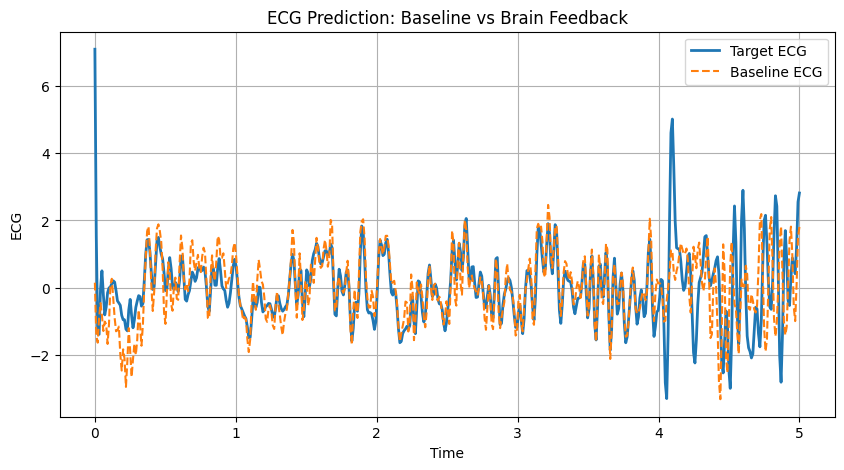

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
timesteps = np.linspace(0,5, len(P_out_baseline))
plt.plot(timesteps,P_out_baseline, label='Target ECG', linewidth=2)
plt.plot(timesteps,eeg_full, label='Baseline ECG', linestyle='--')

plt.title('ECG Prediction: Baseline vs Brain Feedback')
plt.xlabel('Time')
plt.ylabel('ECG')
plt.legend()
plt.grid(True)

plt.show()

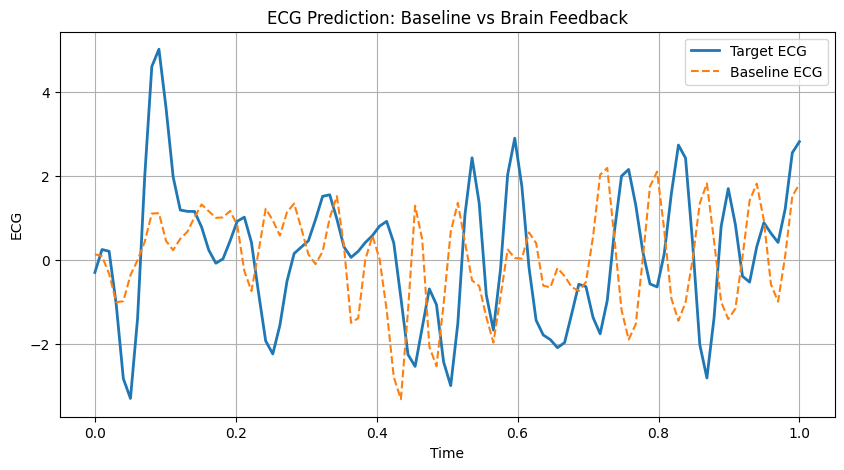

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
timesteps = np.linspace(0,1, len(eeg_test))
plt.plot(timesteps,P_out_baseline[split_idx:], label='Target ECG', linewidth=2)
plt.plot(timesteps,eeg_full[split_idx:], label='Baseline ECG', linestyle='--')

plt.title('ECG Prediction: Baseline vs Brain Feedback')
plt.xlabel('Time')
plt.ylabel('ECG')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
target_indices = [3]
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Using device: {device} ---")

# Step 1: Pre-train heart model
# FIX 4 (support): train_heart_model now also returns heart_losses for plotting
trained_heart_model, heart_losses = train_heart_model(ecg_processed, device)

with torch.no_grad():
    # Change T=10 to T=2 to match the effective duration of ecg_target_signal
    simulated_ecg_input = torch.tensor(simulate_coupled_oscillators(T=4, dt=0.01), dtype=torch.float32).to(device)

    hidden_repr = trained_heart_model.get_features(simulated_ecg_input)

results_folder = "simulation_results"
os.makedirs(results_folder, exist_ok=True)

target_idx = target_indices[0]

t_duration = 4
fs = 100
t = np.arange(0, t_duration, 1/fs)
target_signal = eeg_processed[target_idx, ::10]
D_function = interp1d(t, target_signal, kind='linear', bounds_error=False, fill_value=0.0)

# Step 2: Stage 1 - Brain pre-training (gradient-free forward simulation)
final_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
    eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device
)

--- Using device: cpu ---
--- Starting Heart Model Pre-training ---
Heart Epoch 2500, Loss: 0.198052
Heart Epoch 5000, Loss: 0.069905
Heart Epoch 7500, Loss: 0.065308
Heart Epoch 10000, Loss: 0.062551
Heart Epoch 12500, Loss: 0.057627
Heart Epoch 15000, Loss: 0.052497
Heart Epoch 17500, Loss: 0.048228
Heart Epoch 20000, Loss: 0.044296
Heart Epoch 22500, Loss: 0.040411
Heart Epoch 25000, Loss: 0.035937
--- Heart Pre-training Finished ---

--- Stage 1: Brain Pre-training ---
Brain Epoch 10/30, Loss: 0.956949
Brain Epoch 20/30, Loss: 0.690002
Brain Epoch 30/30, Loss: 0.590358
Brain Epoch 40/30, Loss: 0.544909
Brain Epoch 50/30, Loss: 0.518822
Brain Epoch 60/30, Loss: 0.501103
Brain Epoch 70/30, Loss: 0.487910
Brain Epoch 80/30, Loss: 0.477900
Brain Epoch 90/30, Loss: 0.470418
Brain Epoch 100/30, Loss: 0.464663


In [ ]:
# Step 3: Stage 2 - Train ECG→OscillatorLayer→Brain MLP
trained_mlp_model, mlp_losses = train_mlp_on_frozen_brain(
    trained_heart_model, final_brain_params, Sc_reduced_osc, N, D_function, t, device
)

print("\n--- Extracting Brain rcos_phi for Feedback ---")
with torch.no_grad():
    brain_drive_for_final = torch.tanh(trained_mlp_model(hidden_repr))  ## torch.tanh is not needed
    brain_drive_full = torch.tanh(trained_mlp_model(hidden_repr))  # [T, N]

model = TorchRevHopfNetwork(
    mu=1.0,
    eta_omega=0.0,
    eta_alpha=0.0,
    eta_theta=0.0,
    D_function=D_function,
    N=N,
    Sc=Sc_reduced_osc,
    brain_drive_full=brain_drive_full,
    fs=100,
    device=device
)

r_final, phi_final, theta_final, omega_final, alpha_final, rcos_phi_final = model.solve(
    final_brain_params['r'], final_brain_params['phi'], final_brain_params['theta'],
    final_brain_params['omega'], final_brain_params['alpha'], t
)
print(f"rcos_phi_final shape: {rcos_phi_final.shape}, range: [{rcos_phi_final.min():.3f}, {rcos_phi_final.max():.3f}]")


--- Stage 2: ECG → OscillatorLayer → Brain Training ---


In [ ]:
# ★★★ FINAL PREDICTION & PLOTTING ★★★
print("\n--- Final Predictions ---")
trained_heart_model.eval()
with torch.no_grad():
    # Baseline ECG (no feedback)
    sim_osc_baseline = simulate_coupled_oscillators(T=t_duration, dt=1/fs)
    predicted_ecg_baseline = trained_heart_model(
        torch.tensor(sim_osc_baseline, dtype=torch.float32).to(device)
    ).cpu().numpy().flatten()

    P_out_baseline = torch.sum(alpha_final * r_final * torch.cos(phi_final), axis=1).cpu().numpy()

    simulated_ecg_input_total=torch.tensor(simulate_coupled_oscillators(T=5, dt=0.01), dtype=torch.float32).to(device)
    predicted_ecg_total = trained_heart_model(
        torch.tensor(simulated_ecg_input_total, dtype=torch.float32).to(device)
    ).cpu().numpy().flatten()



target_ecg_t = ecg_processed_total[::10]
timesteps = np.linspace(0,5, len(target_ecg_t))

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(timesteps, target_ecg_t, label='Target ECG', linewidth=2)
plt.plot(timesteps, predicted_ecg_total, label='Baseline ECG', linestyle='--')

plt.title('ECG Prediction: Baseline vs Brain Feedback')
plt.xlabel('Time')
plt.ylabel('ECG')
plt.legend()
plt.grid(True)

plt.show()


--- Final Predictions ---


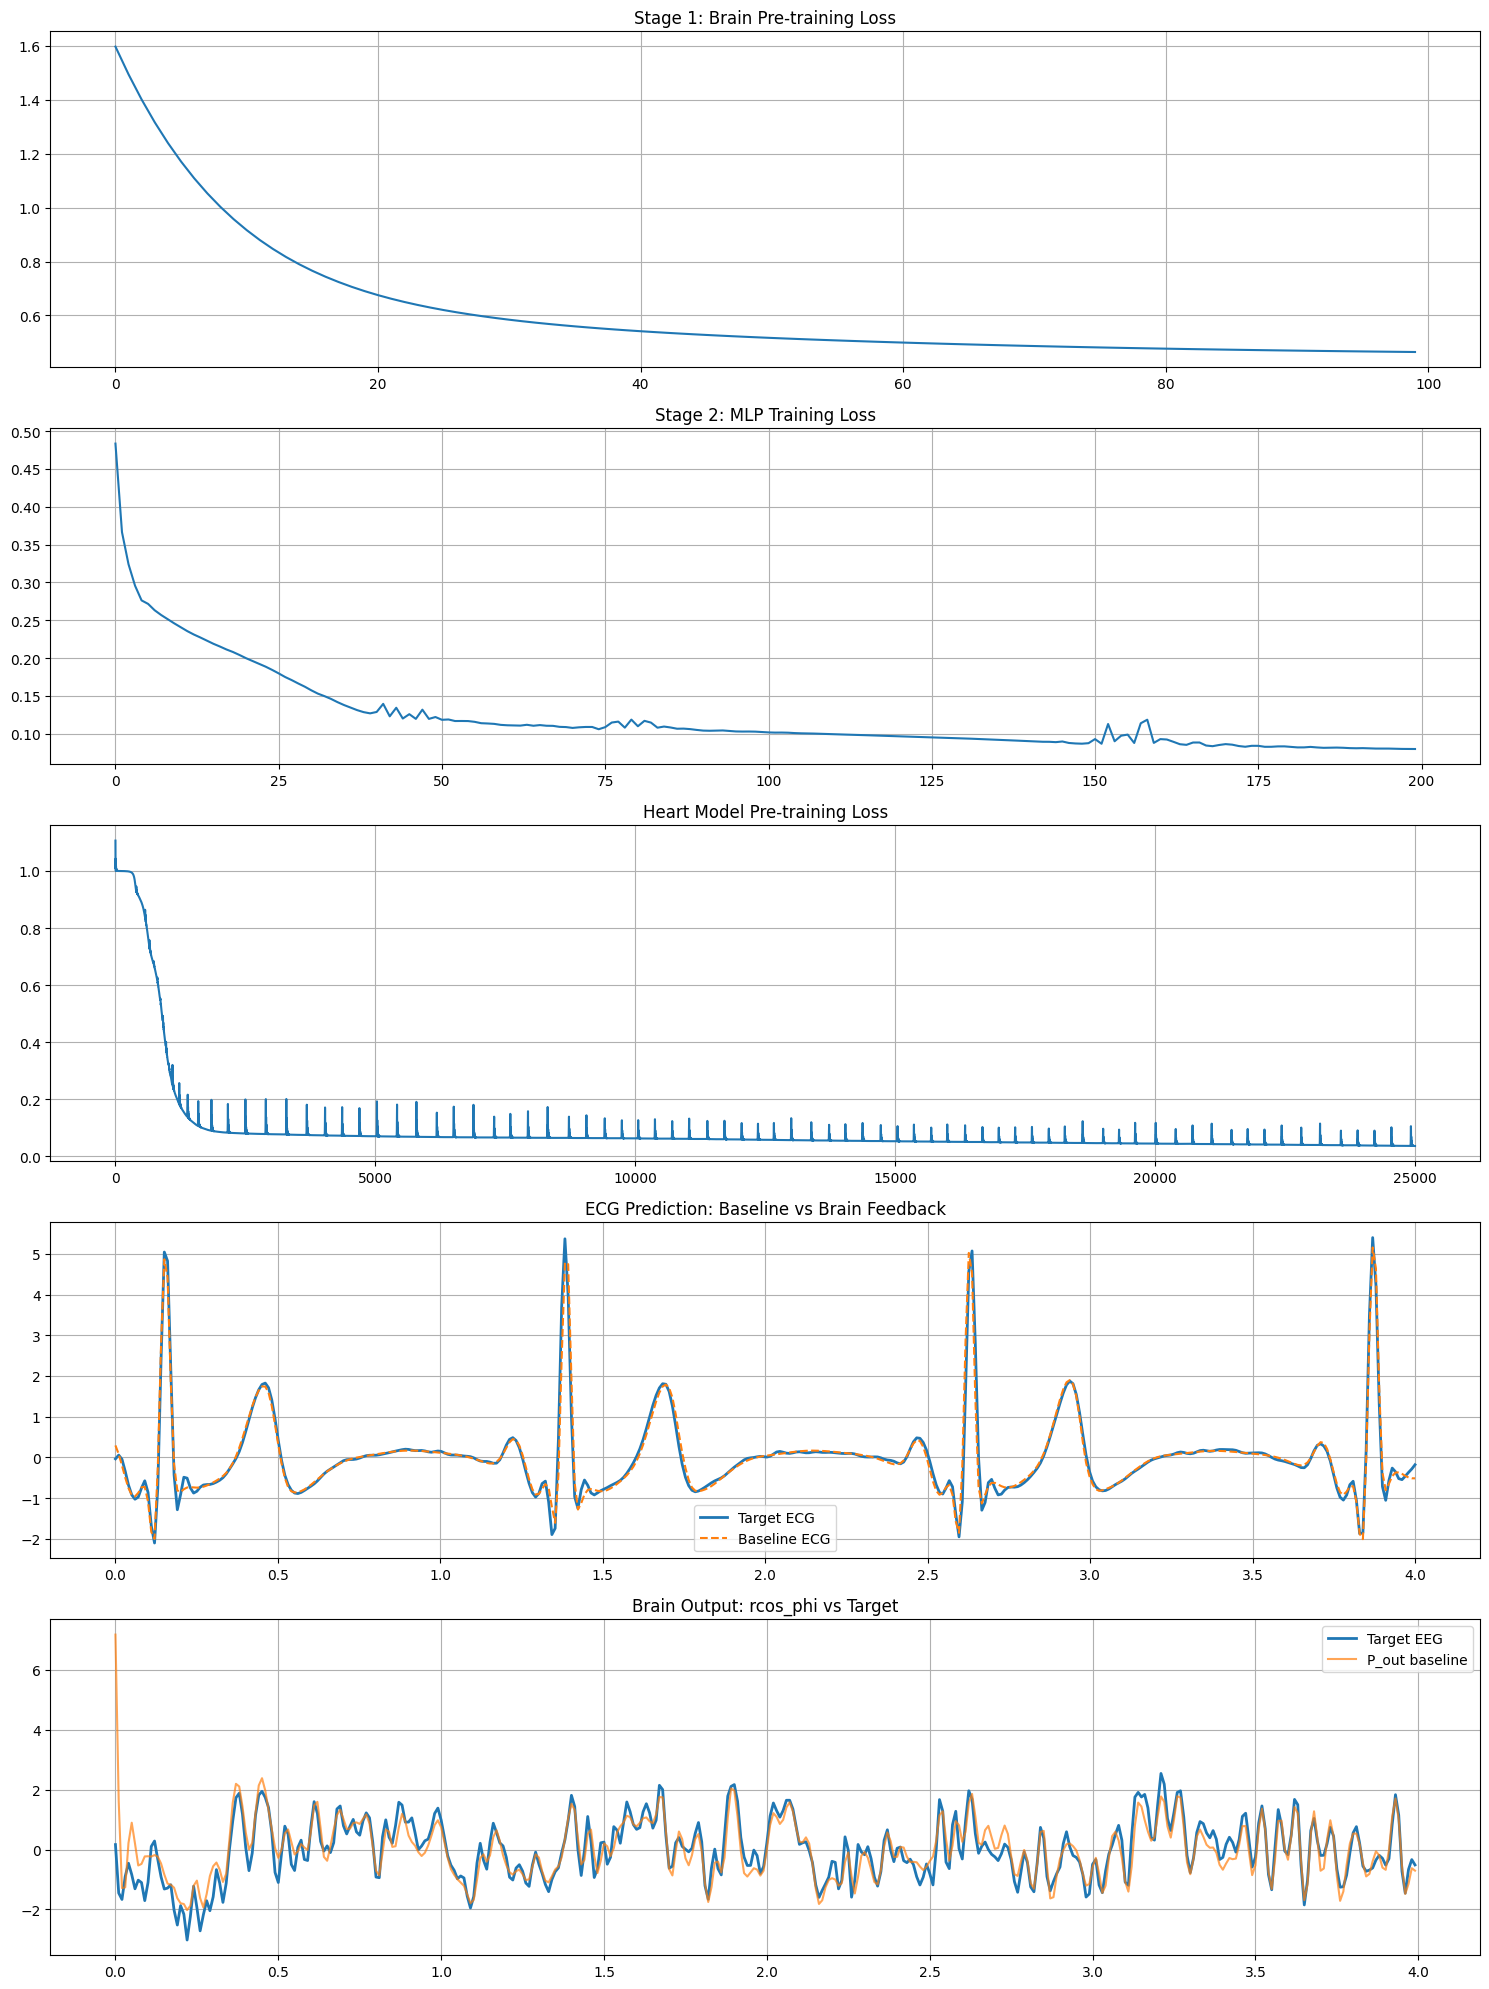

✅ COMPLETE! Check simulation_results/ folder


In [ ]:

fig, axes = plt.subplots(5, 1, figsize=(15, 20))

axes[0].plot(brain_losses)
axes[0].set_title('Stage 1: Brain Pre-training Loss')
axes[0].grid(True)

axes[1].plot(mlp_losses)
axes[1].set_title('Stage 2: MLP Training Loss')
axes[1].grid(True)

# FIX 4: Previously axes[2] was skipped (blank). Now shows heart model loss.
axes[2].plot(heart_losses)
axes[2].set_title('Heart Model Pre-training Loss')
axes[2].grid(True)

target_ecg = ecg_processed[::10]
timesteps = np.linspace(0, t_duration, len(target_ecg))

axes[3].plot(timesteps, target_ecg, label='Target ECG', linewidth=2)
axes[3].plot(timesteps, predicted_ecg_baseline, label='Baseline ECG', linestyle='--')
axes[3].set_title('ECG Prediction: Baseline vs Brain Feedback')
axes[3].legend()
axes[3].grid(True)

axes[4].plot(t, D_function(t), label='Target EEG', linewidth=2)
axes[4].plot(t, P_out_baseline, label='P_out baseline', alpha=0.7)
axes[4].set_title('Brain Output: rcos_phi vs Target')
axes[4].legend()
axes[4].grid(True)

plt.tight_layout()
plt.savefig(f"{results_folder}/full_feedback_result_idx{target_idx}.png", dpi=300, bbox_inches='tight')
plt.show()

np.savez(f"{results_folder}/results_idx{target_idx}.npz",
        brain_losses=brain_losses,
        mlp_losses=mlp_losses,
        heart_losses=heart_losses,
        rcos_phi_final=rcos_phi_final.detach().cpu().numpy(),
        P_out_baseline=P_out_baseline,
        predicted_ecg_baseline=predicted_ecg_baseline,
        target_ecg=target_ecg,
        target_eeg=D_function(t))

print("✅ COMPLETE! Check simulation_results/ folder")